In [1]:
#የአክሲዮን ዋጋ በጊዜ ሂደት እንዴት እንደተቀየረ በተጨማሪ በአክሲዮን ዋጋ እና በግብይት መጠን (Volume) መካከል ግንኙነት አለ የሚሉ እንመለከታለን፡፡

In [2]:
import pandas as pd

# መረጃውን መጫን
df = pd.read_csv('random_stock_market_dataset.csv')

# 'Date' የሚለውን አምድ ወደ datetime መቀየር
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
df.head(5)

,Date,Open,High,Low,Close,Volume
0,2024-01-01,296.45,307.31,293.96,303.72,93133
1,2024-01-02,190.11,193.10,187.21,191.40,64993
2,2024-01-03,197.41,208.64,193.37,205.89,70326
3,2024-01-04,253.13,262.67,248.67,258.95,17358
4,2024-01-05,241.35,253.09,238.99,252.20,20847


In [4]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [5]:
# 'Close' ዋጋ ያለውን የቀን-ለቀን ለውጥ ለማግኘት
df['Daily_Change'] = df['Close'].diff()

# የመጀመሪያዎቹን ጥቂት መረጃዎች ማየት
print(df[['Date', 'Close', 'Daily_Change']].head())

        Date   Close  Daily_Change
0 2024-01-01  303.72           NaN
1 2024-01-02  191.40       -112.32
2 2024-01-03  205.89         14.49
3 2024-01-04  258.95         53.06
4 2024-01-05  252.20         -6.75


In [6]:
# በ ፐርሰንት እንጻር በ 100ኛ
df['Percentage_Change'] = df['Close'].pct_change() * 100
print(df[['Date', 'Close', 'Percentage_Change']].head())

        Date   Close  Percentage_Change
0 2024-01-01  303.72                NaN
1 2024-01-02  191.40         -36.981430
2 2024-01-03  205.89           7.570533
3 2024-01-04  258.95          25.771043
4 2024-01-05  252.20          -2.606681


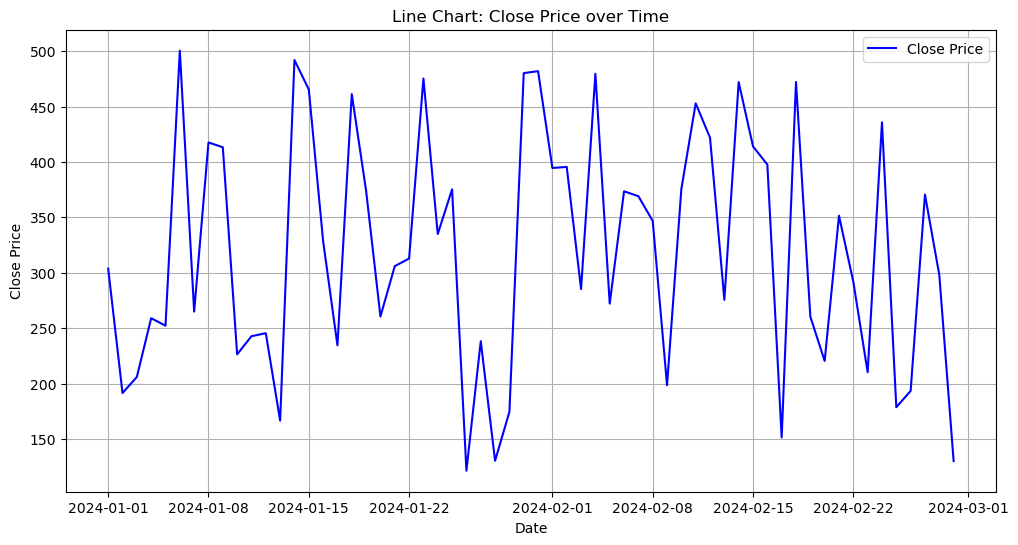

In [7]:
# 'Close' ዋጋ ያለውን የቀን-ለቀን ለውጥ በ line chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot Close price
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')

plt.title('Line Chart: Close Price over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
#ከላይ ግራፉን እንደምናየው ክቀን ጋር በማወዳደር የአክሲዮኑ አዝማሚያውን ያሳያል፡ አክሲዮኑ በአጠቃላይ እየጨመረ፣ እየወደቀ ወይም እየተለዋወጠ መሆኑን እንገነዘባለን

In [9]:
# 1, አማካይ የዝግጅት ዋጋ (Average Close Price)
avg_close = df['Close'].mean()
print(f"አማካይ የዝግጅት ዋጋ (Average Close Price): {avg_close:.2f}")

አማካይ የዝግጅት ዋጋ (Average Close Price): 320.41


In [10]:
# 2. ከፍተኛ እና ዝቅተኛ ዋጋ የተመዘገበባቸው ቀናት
max_row = df.loc[df['Close'].idxmax()]
min_row = df.loc[df['Close'].idxmin()]

print(f"\nከፍተኛ ዋጋ የተመዘገበው በ: {max_row['Date'].date()} (ዋጋ: {max_row['Close']})")
print(f"ዝቅተኛ ዋጋ የተመዘገበው በ: {min_row['Date'].date()} (ዋጋ: {min_row['Close']})")


ከፍተኛ ዋጋ የተመዘገበው በ: 2024-01-06 (ዋጋ: 500.42)
ዝቅተኛ ዋጋ የተመዘገበው በ: 2024-01-26 (ዋጋ: 121.27)


In [11]:
# 3. ግንኙነት (Correlation) በClose ዋጋ እና በVolume መካከል
correlation = df['Close'].corr(df['Volume'])
print(f"\nበClose ዋጋ እና በVolume መካከል ያለው ግንኙነት (Correlation): {correlation:.4f}")


በClose ዋጋ እና በVolume መካከል ያለው ግንኙነት (Correlation): -0.1384


In [12]:
# ውጤቱ ከ 0 በታች ነው: ዋጋው ሲጨምር የግብይት መጠኑ የመቀነስ ዝንባሌ አለው።

C:\Users\Home\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4704 (\N{ETHIOPIC SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Home\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4811 (\N{ETHIOPIC SYLLABLE WAA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Home\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4875 (\N{ETHIOPIC SYLLABLE GAA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Home\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4773 (\N{ETHIOPIC SYLLABLE GLOTTAL E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Home\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4755 (\N{ETHIOPIC SYLLABLE NAA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

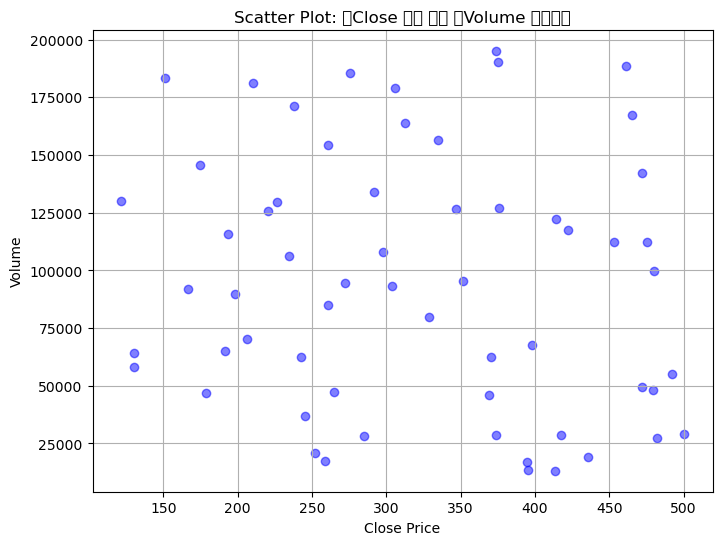

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Close'], df['Volume'], alpha=0.5, color='blue')

plt.title('Scatter Plot: በClose ዋጋ እና በVolume መካከል')
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.grid(True)
plt.show()


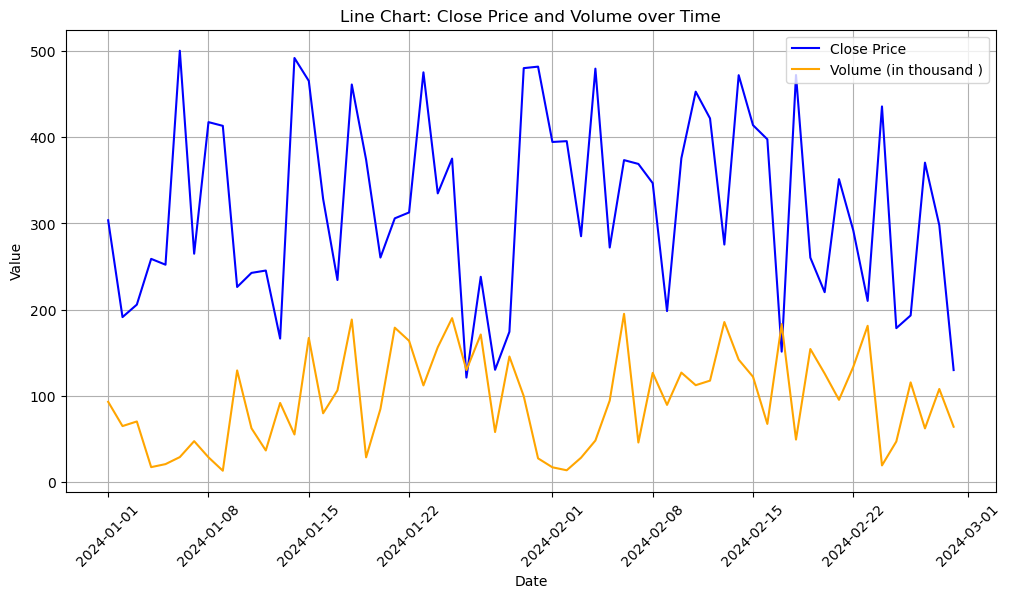

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your DataFrame is named df
# and has columns 'Date', 'Close', and 'Volume'

plt.figure(figsize=(12,6))

# Plot Close price
plt.plot(df['Date'], df['Close'], label='Close Price', color='blue')

# Plot Volume (scaled for visibility)
plt.plot(df['Date'], df['Volume']/1e3, label='Volume (in thousand )', color='orange')

plt.title('Line Chart: Close Price and Volume over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [15]:
# ግኝት (Observation): በ random_stock_market_dataset.csv ላይ የተደረገው የScatter Plot and Line Chart ትንታኔ እንደሚያሳየው፣ በአክሲዮኑ የመዝጊያ ዋጋ እና በግብይት መጠኑ (Volume) መካከል ጠንካራ ግንኙነት የለም።
# ምክንያታዊ ትንታኔ (Analysis): ይህ ማለት የአክሲዮኑ ዋጋ መለዋወጥ በግብይት መጠኑ ብቻ የሚወሰን ላይሆን ይችላል። እንደ ውጫዊ የገበያ ሁኔታዎች ወይም የዜና ክስተቶች ያሉ ሌሎች ነገሮች ተጽእኖ ሊኖራቸው ይችላል።

In [16]:
# በወር አማካይ ዋጋ
monthly_avg = df.set_index('Date').resample('ME')['Close'].mean()
print("የየወሩ አማካይ የዝግጅት ዋጋ:")
print(monthly_avg)

የየወሩ አማካይ የዝግጅት ዋጋ:
Date
2024-01-31    314.066452
2024-02-29    327.196552
Freq: ME, Name: Close, dtype: float64


In [17]:
# በወር አማካይ volume(የግብይት መጠን) 
monthly_avg = df.set_index('Date').resample('ME')['Volume'].mean()
print("የየወሩ አማካይ የግብይት መጠን:")
print(monthly_avg)

የየወሩ አማካይ የግብይት መጠን:
Date
2024-01-31    91949.741935
2024-02-29    99099.620690
Freq: ME, Name: Volume, dtype: float64


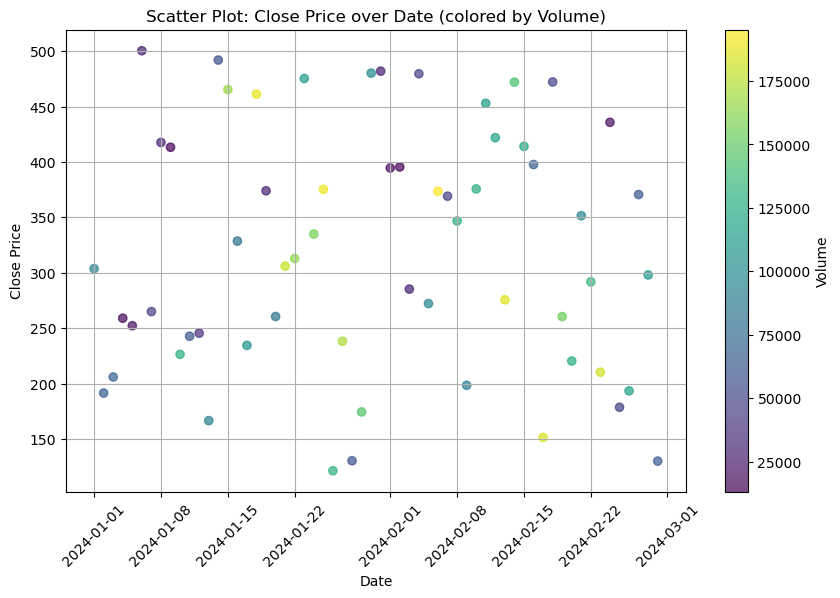

In [18]:
# በClose ዋጋ እና በVolume መካከል ዋጋ በጊዜ ሂደት የነበረውን የመዝጊያ ዋጋ (Close Price) እና በየቀኑ የነበረውን የግብይት መጠን (Volume) በአንድ ላይ እንዲታይ ያስችላል 
plt.figure(figsize=(10,6))
plt.scatter(df['Date'], df['Close'], 
            c=df['Volume'], cmap='viridis', alpha=0.7)

plt.title('Scatter Plot: Close Price over Date (colored by Volume)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.colorbar(label='Volume')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [19]:
# 1. አማካይ ዋጋ (Average Price) 
avg_close = df['Close'].mean()

# 2. ከፍተኛ እና ዝቅተኛ ዋጋ እና ቀናቶቻቸው 
max_row = df.loc[df['Close'].idxmax()]
min_row = df.loc[df['Close'].idxmin()]

# 3. ግንኙነት (Correlation) 
correlation = df['Close'].corr(df['Volume'])

# ውጤቱን ማተም 
print(f"አማካይ ዋጋ: {avg_close:.2f}")
print(f"ከፍተኛ ዋጋ: {max_row['Close']} በ {max_row['Date'].date()}")
print(f"ዝቅተኛ ዋጋ: {min_row['Close']} በ {min_row['Date'].date()}")
print(f"ግንኙነት: {correlation:.4f}")

አማካይ ዋጋ: 320.41
ከፍተኛ ዋጋ: 500.42 በ 2024-01-06
ዝቅተኛ ዋጋ: 121.27 በ 2024-01-26
ግንኙነት: -0.1384


In [20]:
# To detect outliers in your stock market dataset (especially in Close and Volume)

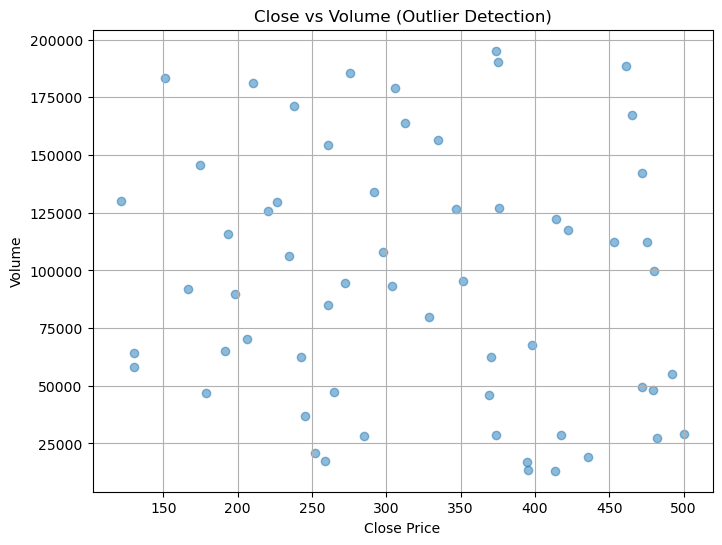

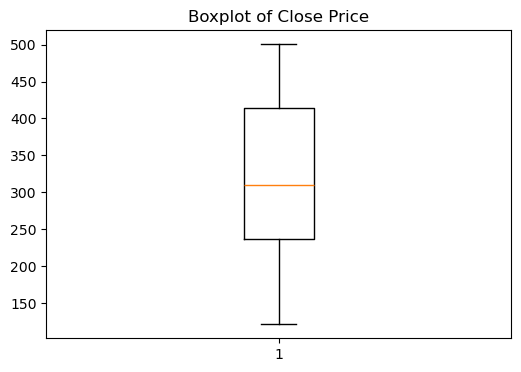

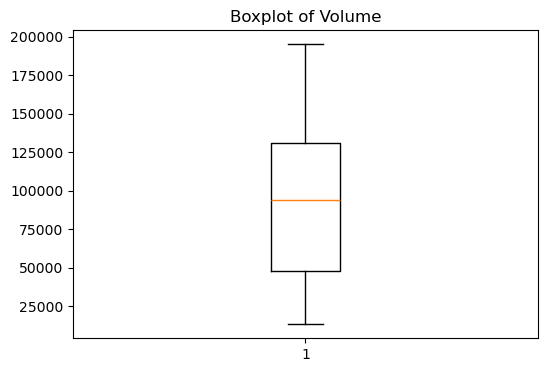

In [21]:
import matplotlib.pyplot as plt

# Scatter plot Close vs Volume
plt.figure(figsize=(8,6))
plt.scatter(df['Close'], df['Volume'], alpha=0.5)
plt.title('Close vs Volume (Outlier Detection)')
plt.xlabel('Close Price')
plt.ylabel('Volume')
plt.grid(True)
plt.show()

# Boxplot for Close
plt.figure(figsize=(6,4))
plt.boxplot(df['Close'])
plt.title('Boxplot of Close Price')
plt.show()

# Boxplot for Volume
plt.figure(figsize=(6,4))
plt.boxplot(df['Volume'])
plt.title('Boxplot of Volume')
plt.show()


In [22]:
# Statistical Detection
import numpy as np

def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return series[(series < lower_bound) | (series > upper_bound)]

outliers_close = detect_outliers(df['Close'])
outliers_volume = detect_outliers(df['Volume'])

print("Outliers in Close:\n", outliers_close)
print("Outliers in Volume:\n", outliers_volume)

Outliers in Close:
 Series([], Name: Close, dtype: float64)
Outliers in Volume:
 Series([], Name: Volume, dtype: int64)


In [24]:
### ማጠቃለያ (Summary)፦
# - የዋጋ መዋዠቅ (Price Volatility): በመዝጊያ ዋጋ (Close Price) ላይ የሚታዩት ያልተለመዱ እሴቶች (Outliers)፣ በገበያው ውስጥ በድንገት የሚከሰቱ ለመተንበይ አስቸጋሪ የሆኑ ከፍተኛ የዋጋ ለውጦችን ያመለክታሉ።
# - ግብይት እንቅስቃሴ (Trading Activity): በግብይት መጠን (Volume) ላይ የሚታዩት Outliers፣ አክሲዮኑ በተለመደው የንግድ እንቅስቃሴ ውስጥ ከነበረው ደረጃ በዘለለ ከፍተኛ ወይም ዝቅተኛ እንቅስቃሴ እንደነበረ ያሳያሉ።
# - ማጠቃለያ: እነዚህን መረጃዎች በአንድ ላይ መተንተን፣ በገበያው ውስጥ ያሉ ያልተለመዱ ክስተቶችን (market anomalies) ለመለየት እና ለተጨማሪ ጥናት የሚያነሳሱ ወሳኝ ነጥቦችን እንድናገኝ ያስችለናል።